<a href="https://colab.research.google.com/github/cabreonictor/Visualizacion-y-Narrativa-de-Datos/blob/main/TP2/Vis_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Visualización y Narrativa de Datos**
##**Proyecto Integrador Unidad I**
###**Del dato a la decisión**

#**Análisis Inicial**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**1. ¿Qué representa cada variable en el dataset?**
#**2. ¿Qué tipo de dato contiene cada columna?**





In [40]:
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')
df.head()

,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          506 non-null    int64  
 1   Fecha       506 non-null    object 
 2   Unidad      506 non-null    object 
 3   Region      506 non-null    object 
 4   Actividad   506 non-null    float64
 5   Horas       498 non-null    float64
 6   Recursos    506 non-null    int64  
 7   Incidentes  506 non-null    int64  
 8   Tiempo      498 non-null    float64
 9   Calidad     498 non-null    float64
 10  Costo       506 non-null    float64
 11  Resultado   506 non-null    float64
dtypes: float64(6), int64(3), object(3)
memory usage: 47.6+ KB


El datase parece contener variables relativas a una activdad de una empresa u organización.

ID: Identificador de registro. Tipo Entero.

Fecha: Fecha de la operación. Tipo Fecha.

Unidad: Unidad de negocio. Tipo Texto.

Region: Ubicación geográfica. Tipo Texto.

Actividad: Cantidad de actividad realizada. Tipo Decimal.

Horas: Cantidad de horas trabajadas. Tipo Decimal.

Recursos: Cantidad de recursos utilizados. Tipo Entero.

Incidentes: Cantidad de eventono previstos ocurridos. Tipo Entero.

Tiempo: Duración del incidente o duración del resultado. Tipo Decimal.

Calidad: Porcentaje de una escala de calidad. Tipo Decimal.

Costo: Costo total de la operación. Tipo Decimal.

Resultado: Valor obtenido de la característca del objetivo. Tipo Decimal.


#**3. ¿Qué período temporal abarca la información**

In [42]:
fecha_inicio = pd.to_datetime(df['Fecha']).min()
fecha_fin = pd.to_datetime(df['Fecha']).max()
print(f"El dataset abarca desde {fecha_inicio} hasta {fecha_fin}")
periodo_total = fecha_fin - fecha_inicio
print(f"El periodo total de tiempo es de {periodo_total}")

El dataset abarca desde 2023-01-02 00:00:00 hasta 2025-06-25 00:00:00
El periodo total de tiempo es de 905 days 00:00:00


#**4. ¿Qué calidad presentan los datos? ¿Existen valores faltantes, duplicados o inconsistencias?**

In [43]:
# Duplicados
print(f'Duplicados: {df.duplicated().sum()}')

# Valores faltantes
print(f'Valores faltantes:')
print(f'{df.isna().sum()}')
print(f'Total de valores faltantes: {df.isna().sum().sum()}')

Duplicados: 6
Valores faltantes:
ID            0
Fecha         0
Unidad        0
Region        0
Actividad     0
Horas         8
Recursos      0
Incidentes    0
Tiempo        8
Calidad       8
Costo         0
Resultado     0
dtype: int64
Total de valores faltantes: 24


Como se puede ver, existen 6 filas duplicadas y 24 valores faltantes.

<Axes: >

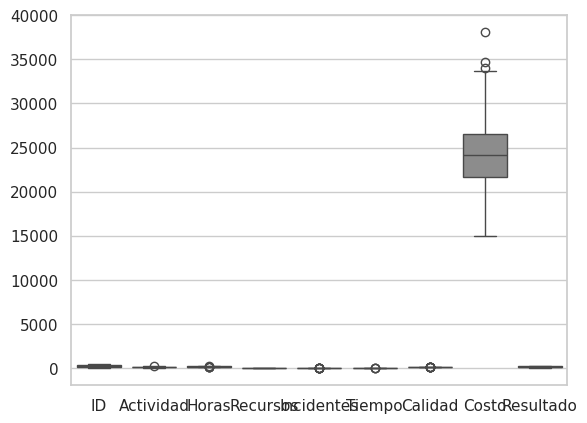

In [44]:
sns.boxplot(data = df)

Se pueden ver outliers en 6 variales.

#**5. ¿Qué información consideran que falta para realizar un análisis más completo?**

El dataset no tiene un documento con la información explicativa de cada variable, como son los diccionarios de datos. No se sabe qué representa cada variable, ni las unidades de medidas. Tampoco se saben el rango de valores permitidos. Todo esto impide hacer un análisis más completo.

#**6. ¿Qué indicadores (KPIs) consideran relevantes?**


Debido a la falta de información los KPIs relevantes estarán dados por los valores medios de las diferentes variables que representen a la operación, tal como el valor promedio de los Resultados, de los Costos por Resultado, de los Incidentes, de la Calidad y Resultados por Hora.

In [45]:
print(f'Valor promedio de los Resultados: {df["Resultado"].mean()}')
costo_resultado = df["Costo"] / df["Resultado"]
print(f'Valor promedio de los Costos por Resultado: {costo_resultado.mean()}')
print(f'Valor promedio de los Incidentes: {df["Incidentes"].mean()}')
print(f'Valor promedio de la Calidad: {df["Calidad"].mean()}')
resultado_hora = df["Resultado"] / df["Horas"]
print(f'Valor promedio de los resultados por Hora: {resultado_hora.mean()}')

Valor promedio de los Resultados: 165.96865612648224
Valor promedio de los Costos por Resultado: 153.40254709383032
Valor promedio de los Incidentes: 2.367588932806324
Valor promedio de la Calidad: 89.94738955823294
Valor promedio de los resultados por Hora: 1.0248944065134218


#**7. ¿Qué visualizaciones utilizarían y por qué?**
Las visualizaciones a utilizar son los gráfico de barras, para comparar los valores alcanzados entre distintas categorías de una variable, valores temporales para ver la evolución, boxplots para detectar outliers, gráficos de dispersión para ver la correlación entre variables, y matriz de correlación de Pearson, para tener un panorama completo.

#**8. ¿Qué decisiones recomendarían a la organización únicamente con la información disponible?**

#**9. ¿Qué supuestos debieron realizar durante el análisis?**
Los supuestos considerados fueron los siguientes:
1. El dataset corresponde con la operación de un negocio, empresa u organización.
2. La variable Resultado representa el objetivo principal de la operación.
3. Cada fila del dataset representa una operación completa.
4. La variable Calidad es una forma de validar el Resultado.




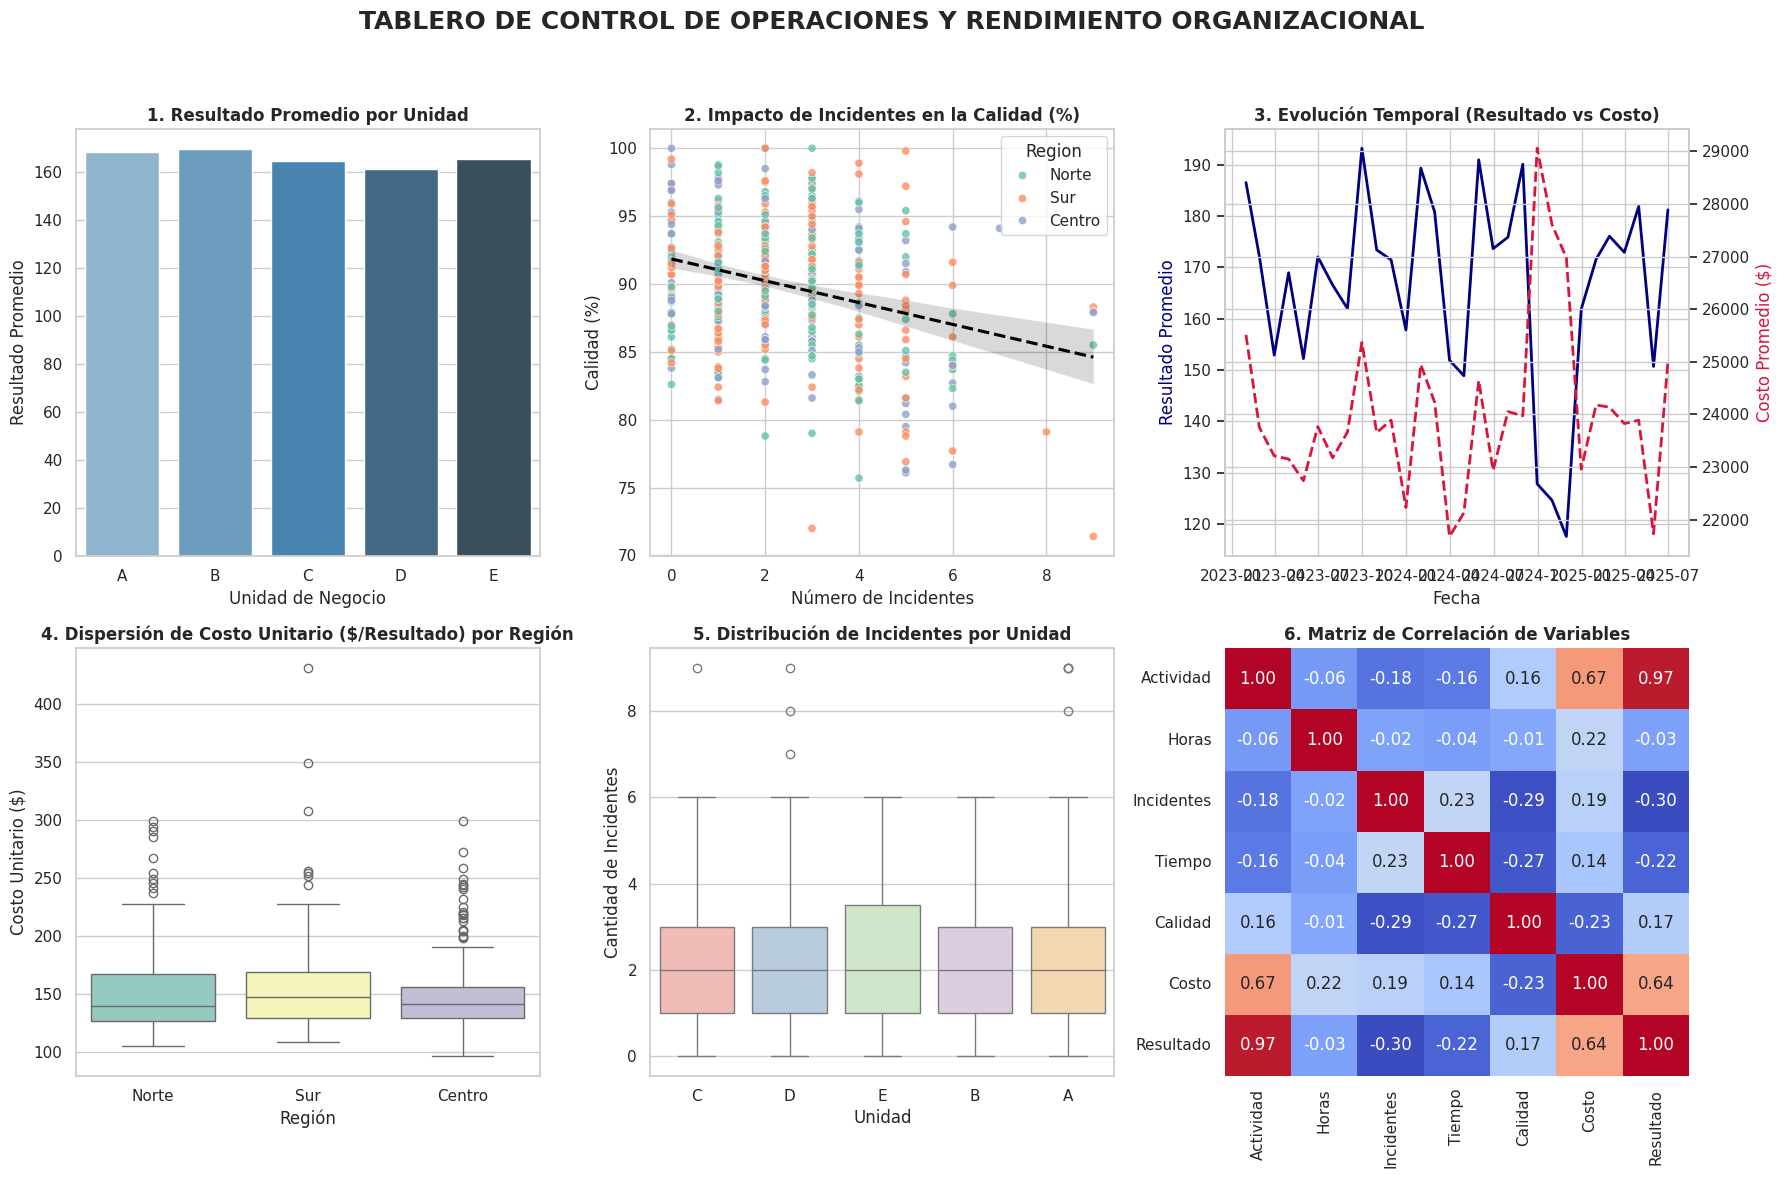

In [46]:
# Configuración de estilo y compatibilidad de tipografías (Windows / Colab / Linux)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'Segoe UI', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# 1. Cargar y limpiar datos
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')
df = df.drop_duplicates()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Crear variables métricas derivadas
df['Costo_Unitario'] = df['Costo'] / df['Resultado']
df['Productividad_Hora'] = df['Resultado'] / df['Horas']

# 2. Configurar la figura del Dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle('TABLERO DE CONTROL DE OPERACIONES Y RENDIMIENTO ORGANIZACIONAL', fontsize=18, fontweight='bold', y=0.98)

# Gráfico 1: Resultado Promedio por Unidad (Actualizado con hue y legend=False)
ax1 = plt.subplot(2, 3, 1)
unidad_metrics = df.groupby('Unidad')[['Resultado', 'Costo_Unitario']].mean().reset_index()
sns.barplot(
    data=unidad_metrics,
    x='Unidad',
    y='Resultado',
    hue='Unidad',
    palette='Blues_d',
    legend=False,
    ax=ax1
)
ax1.set_title('1. Resultado Promedio por Unidad', fontsize=12, fontweight='bold')
ax1.set_ylabel('Resultado Promedio')
ax1.set_xlabel('Unidad de Negocio')

# Gráfico 2: Relación Incidentes vs Calidad
ax2 = plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='Incidentes', y='Calidad', hue='Region', palette='Set2', alpha=0.8, ax=ax2)
sns.regplot(data=df, x='Incidentes', y='Calidad', scatter=False, ax=ax2, color='black', line_kws={'linestyle': '--'})
ax2.set_title('2. Impacto de Incidentes en la Calidad (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Incidentes')
ax2.set_ylabel('Calidad (%)')

# Gráfico 3: Evolución Temporal (Resultado vs Costo)
ax3 = plt.subplot(2, 3, 3)
df_monthly = df.resample('ME', on='Fecha')[['Resultado', 'Costo']].mean().reset_index()
ax3.plot(df_monthly['Fecha'], df_monthly['Resultado'], label='Resultado', color='navy', linewidth=2)
ax3_twin = ax3.twinx()
ax3_twin.plot(df_monthly['Fecha'], df_monthly['Costo'], label='Costo ($)', color='crimson', linestyle='--', linewidth=2)
ax3.set_title('3. Evolución Temporal (Resultado vs Costo)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Fecha')
ax3.set_ylabel('Resultado Promedio', color='navy')
ax3_twin.set_ylabel('Costo Promedio ($)', color='crimson')

# Gráfico 4: Costo Unitario por Región (Actualizado con hue y legend=False)
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(
    data=df,
    x='Region',
    y='Costo_Unitario',
    hue='Region',
    palette='Set3',
    legend=False,
    ax=ax4
)
ax4.set_title('4. Dispersión de Costo Unitario ($/Resultado) por Región', fontsize=12, fontweight='bold')
ax4.set_xlabel('Región')
ax4.set_ylabel('Costo Unitario ($)')

# Gráfico 5: Distribución de Incidentes por Unidad (Actualizado con hue y legend=False)
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(
    data=df,
    x='Unidad',
    y='Incidentes',
    hue='Unidad',
    palette='Pastel1',
    legend=False,
    ax=ax5
)
ax5.set_title('5. Distribución de Incidentes por Unidad', fontsize=12, fontweight='bold')
ax5.set_xlabel('Unidad')
ax5.set_ylabel('Cantidad de Incidentes')

# Gráfico 6: Mapa de Calor de Correlaciones Operativas
ax6 = plt.subplot(2, 3, 6)
corr_cols = ['Actividad', 'Horas', 'Incidentes', 'Tiempo', 'Calidad', 'Costo', 'Resultado']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=ax6, cbar=False)
ax6.set_title('6. Matriz de Correlación de Variables', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_1502/3013195543.py:78: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M', on='Fecha')[['Resultado', 'Costo']].mean().reset_index()


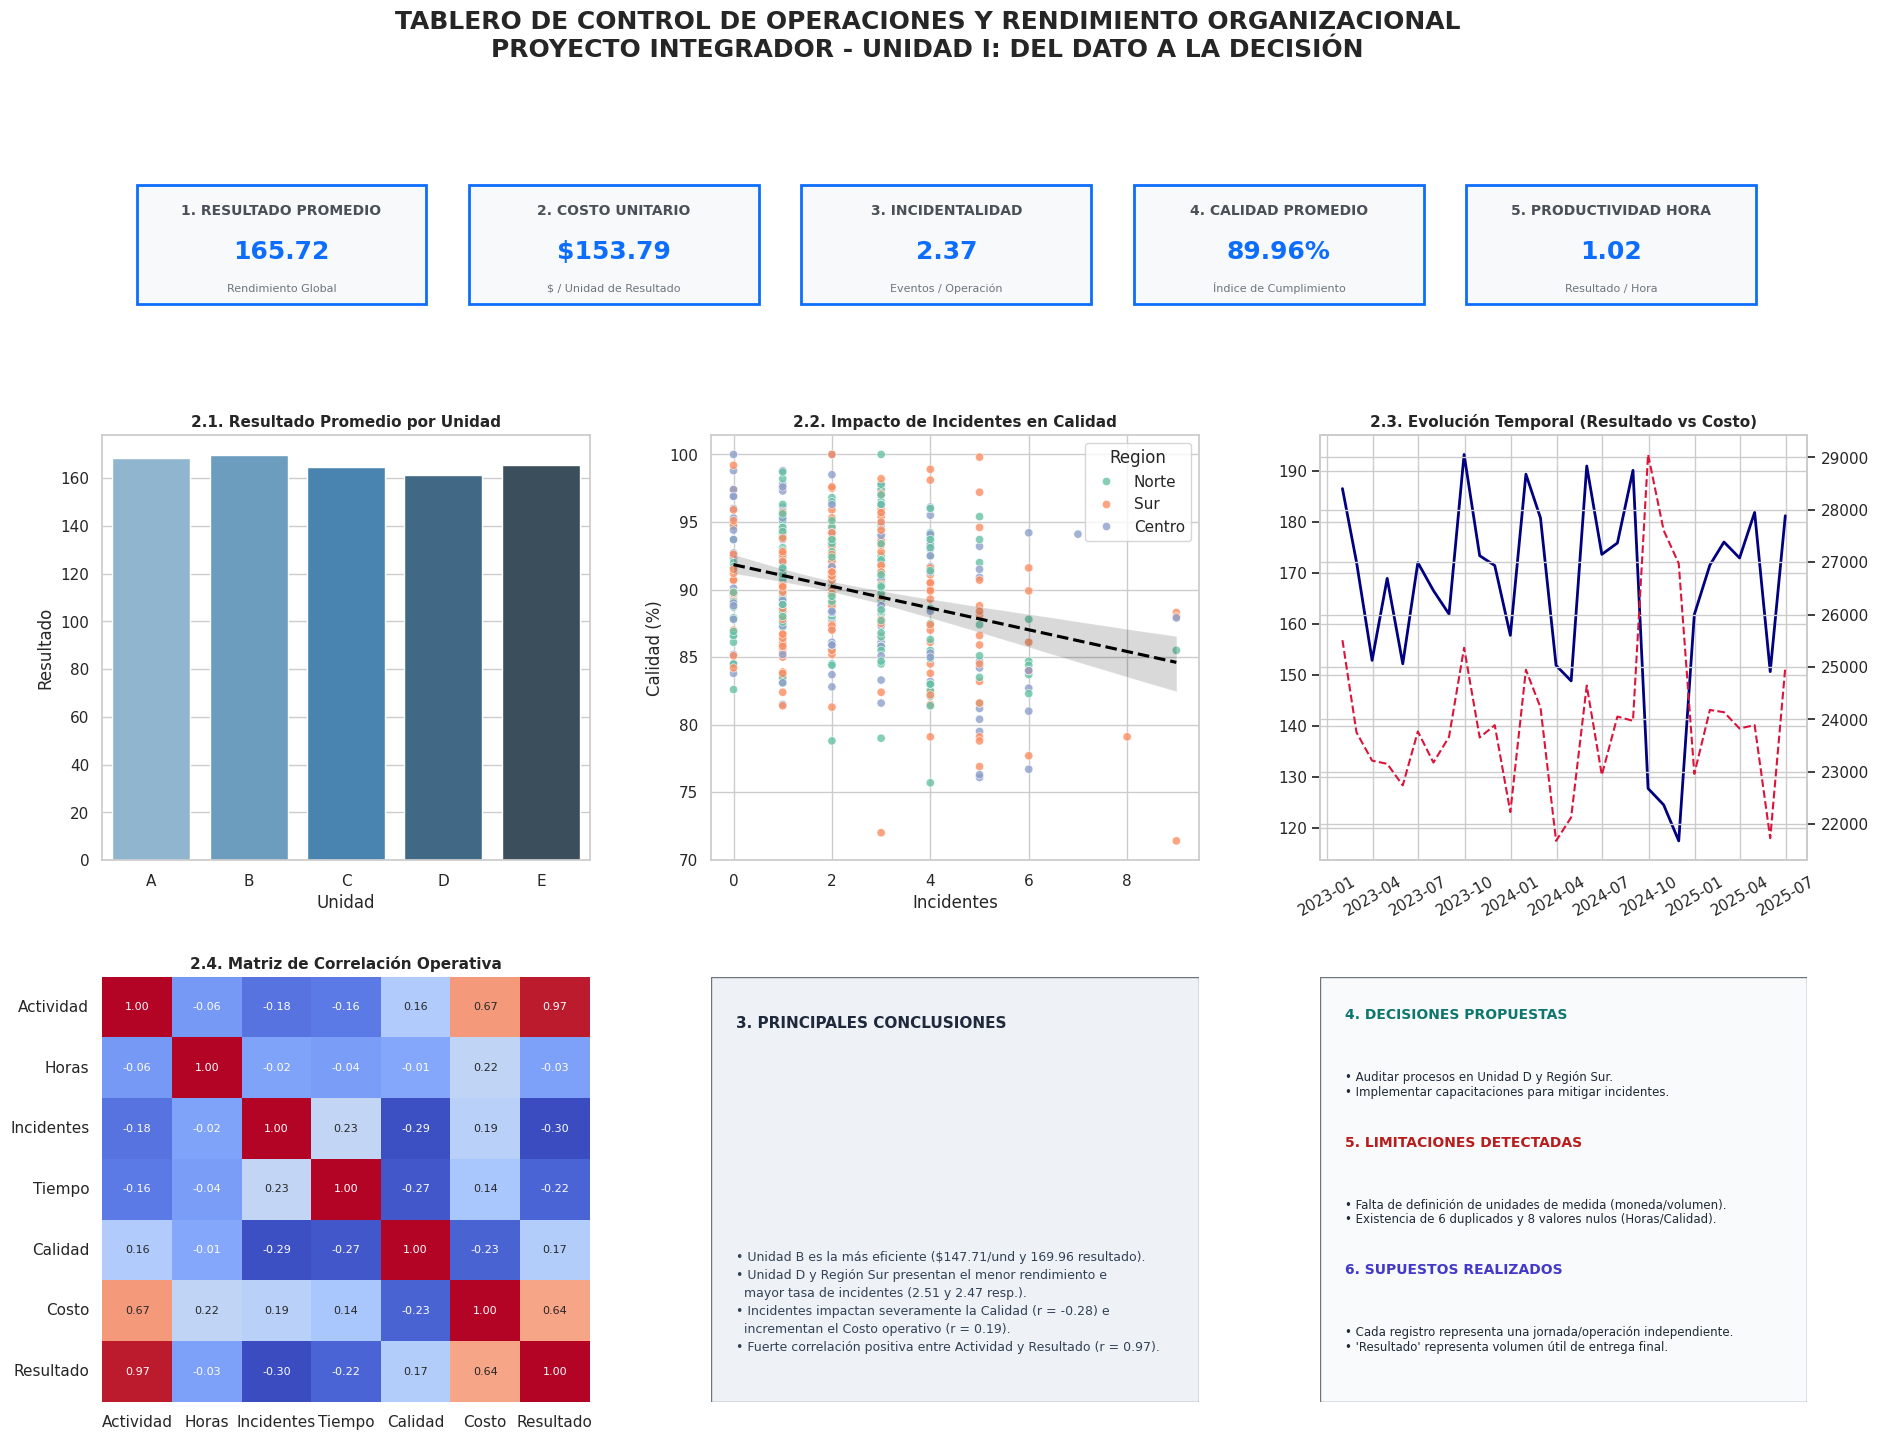

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo y compatibilidad de tipografías
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'Segoe UI', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# 1. Cargar y limpiar datos
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')

df = df.drop_duplicates()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Variables métricas derivadas
df['Costo_Unitario'] = df['Costo'] / df['Resultado']
df['Productividad_Hora'] = df['Resultado'] / df['Horas']

# Crear figura con distribución de paneles (GridSpec)
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3, height_ratios=[0.35, 1, 1], hspace=0.35, wspace=0.25)

fig.suptitle('TABLERO DE CONTROL DE OPERACIONES Y RENDIMIENTO ORGANIZACIONAL\nPROYECTO INTEGRADOR - UNIDAD I: DEL DATO A LA DECISIÓN',
             fontsize=18, fontweight='bold', y=0.98)

# -------------------------------------------------------------
# PANEL 1: INDICADORES SELECCIONADOS (KPIs Cards)
# -------------------------------------------------------------
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

# Calcular valores
kpi1_val = f"{df['Resultado'].mean():.2f}"
kpi2_val = f"${df['Costo_Unitario'].mean():.2f}"
kpi3_val = f"{df['Incidentes'].mean():.2f}"
kpi4_val = f"{df['Calidad'].mean():.2f}%"
kpi5_val = f"{df['Productividad_Hora'].mean():.2f}"

kpis = [
    ("1. RESULTADO PROMEDIO", kpi1_val, "Rendimiento Global"),
    ("2. COSTO UNITARIO", kpi2_val, "$ / Unidad de Resultado"),
    ("3. INCIDENTALIDAD", kpi3_val, "Eventos / Operación"),
    ("4. CALIDAD PROMEDIO", kpi4_val, "Índice de Cumplimiento"),
    ("5. PRODUCTIVIDAD HORA", kpi5_val, "Resultado / Hora")
]

for i, (title, val, sub) in enumerate(kpis):
    x = 0.02 + i * 0.195
    rect = plt.Rectangle((x, 0.1), 0.17, 0.8, transform=ax_kpi.transAxes,
                         facecolor='#f8f9fa', edgecolor='#0d6efd', linewidth=2)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x + 0.085, 0.70, title, transform=ax_kpi.transAxes, ha='center', fontsize=10, fontweight='bold', color='#495057')
    ax_kpi.text(x + 0.085, 0.40, val, transform=ax_kpi.transAxes, ha='center', fontsize=18, fontweight='bold', color='#0d6efd')
    ax_kpi.text(x + 0.085, 0.18, sub, transform=ax_kpi.transAxes, ha='center', fontsize=8, color='#6c757d')

# -------------------------------------------------------------
# PANEL 2: VISUALIZACIONES UTILIZADAS
# -------------------------------------------------------------
# Vis 1: Barplot por Unidad
ax1 = fig.add_subplot(gs[1, 0])
unidad_metrics = df.groupby('Unidad')['Resultado'].mean().reset_index()
sns.barplot(data=unidad_metrics, x='Unidad', y='Resultado', hue='Unidad', palette='Blues_d', ax=ax1)
if ax1.get_legend(): ax1.get_legend().remove()
ax1.set_title('2.1. Resultado Promedio por Unidad', fontsize=11, fontweight='bold')
ax1.set_ylabel('Resultado')

# Vis 2: Scatterplot Incidentes vs Calidad
ax2 = fig.add_subplot(gs[1, 1])
sns.scatterplot(data=df, x='Incidentes', y='Calidad', hue='Region', palette='Set2', alpha=0.8, ax=ax2)
sns.regplot(data=df, x='Incidentes', y='Calidad', scatter=False, ax=ax2, color='black', line_kws={'linestyle': '--'})
ax2.set_title('2.2. Impacto de Incidentes en Calidad', fontsize=11, fontweight='bold')
ax2.set_ylabel('Calidad (%)')

# Vis 3: Serie Temporal
ax3 = fig.add_subplot(gs[1, 2])
df_monthly = df.resample('M', on='Fecha')[['Resultado', 'Costo']].mean().reset_index()
ax3.plot(df_monthly['Fecha'], df_monthly['Resultado'], color='navy', linewidth=2, label='Resultado')
ax3_twin = ax3.twinx()
ax3_twin.plot(df_monthly['Fecha'], df_monthly['Costo'], color='crimson', linestyle='--', linewidth=1.5, label='Costo')
ax3.set_title('2.3. Evolución Temporal (Resultado vs Costo)', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

# Vis 4: Matriz de Correlación
ax4 = fig.add_subplot(gs[2, 0])
corr_cols = ['Actividad', 'Horas', 'Incidentes', 'Tiempo', 'Calidad', 'Costo', 'Resultado']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=ax4, cbar=False, annot_kws={"size": 8})
ax4.set_title('2.4. Matriz de Correlación Operativa', fontsize=11, fontweight='bold')

# -------------------------------------------------------------
# PANELS 3, 4, 5, 6: PANELES TEXTUALES INTEGRADOS EN EL TABLERO
# -------------------------------------------------------------

# Panel 3: Principales Conclusiones
ax_text1 = fig.add_subplot(gs[2, 1])
ax_text1.axis('off')
rect_c = plt.Rectangle((0, 0), 1, 1, transform=ax_text1.transAxes, facecolor='#eef2f7', edgecolor='#6c757d', linewidth=1)
ax_text1.add_patch(rect_c)
ax_text1.text(0.05, 0.88, '3. PRINCIPALES CONCLUSIONES', fontsize=11, fontweight='bold', color='#1e293b')
text_conclusiones = (
    "• Unidad B es la más eficiente ($147.71/und y 169.96 resultado).\n"
    "• Unidad D y Región Sur presentan el menor rendimiento e\n"
    "  mayor tasa de incidentes (2.51 y 2.47 resp.).\n"
    "• Incidentes impactan severamente la Calidad (r = -0.28) e\n"
    "  incrementan el Costo operativo (r = 0.19).\n"
    "• Fuerte correlación positiva entre Actividad y Resultado (r = 0.97)."
)
ax_text1.text(0.05, 0.12, text_conclusiones, fontsize=9, color='#334155', linespacing=1.5)

# Panel 4, 5, 6: Decisiones, Limitaciones y Supuestos
ax_text2 = fig.add_subplot(gs[2, 2])
ax_text2.axis('off')
rect_d = plt.Rectangle((0, 0), 1, 1, transform=ax_text2.transAxes, facecolor='#f8fafc', edgecolor='#6c757d', linewidth=1)
ax_text2.add_patch(rect_d)

ax_text2.text(0.05, 0.90, '4. DECISIONES PROPUESTAS', fontsize=10, fontweight='bold', color='#0f766e')
text_decisiones = (
    "• Auditar procesos en Unidad D y Región Sur.\n"
    "• Implementar capacitaciones para mitigar incidentes."
)
ax_text2.text(0.05, 0.72, text_decisiones, fontsize=8.5, color='#1f2937')

ax_text2.text(0.05, 0.60, '5. LIMITACIONES DETECTADAS', fontsize=10, fontweight='bold', color='#b91c1c')
text_limitaciones = (
    "• Falta de definición de unidades de medida (moneda/volumen).\n"
    "• Existencia de 6 duplicados y 8 valores nulos (Horas/Calidad)."
)
ax_text2.text(0.05, 0.42, text_limitaciones, fontsize=8.5, color='#1f2937')

ax_text2.text(0.05, 0.30, '6. SUPUESTOS REALIZADOS', fontsize=10, fontweight='bold', color='#4338ca')
text_supuestos = (
    "• Cada registro representa una jornada/operación independiente.\n"
    "• 'Resultado' representa volumen útil de entrega final."
)
ax_text2.text(0.05, 0.12, text_supuestos, fontsize=8.5, color='#1f2937')

plt.savefig('dashboard_integrado_final.png', bbox_inches='tight', dpi=300)
plt.show()

#**TRABAJO PRÁCTICO 2**

#**1. Información nueva**
##Se trata de una actividad bancaria, del Banco Regional del Norte. La actividad consiste en la aprobación o rechazo de pedidos de préstamo.
Además, se recibión información relacionada con el coportamiento inusual del período que abarca de Septiembre a Noviembr del 2024.

In [48]:
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')
df.drop_duplicates().dropna()
df.rename(columns = {
  'ID': 'id_solicitud',
  'Fecha': 'fecha_operacion',
  'Unidad': 'tipo_credito',
  'Region': 'region_sucursal',
  'Actividad': 'solicitudes_evaluadas',
  'Horas': 'horas_evaluacion',
  'Recursos': 'analistas_asignados',
  'Incidentes':'mora_alertas_documentos',
  'Tiempo': 'tiempo_resolucion_dias',
  'Calidad': 'indice_cobrabilidad_porcentual',
  'Costo': 'costo_seguimiento',
  'Resultado': 'creditos_ortorgados'

}, inplace = True)
df.head()

,id_solicitud,fecha_operacion,tipo_credito,region_sucursal,solicitudes_evaluadas,horas_evaluacion,analistas_asignados,mora_alertas_documentos,tiempo_resolucion_dias,indice_cobrabilidad_porcentual,costo_seguimiento,creditos_ortorgados
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0


#**2. Conclusiones que siguen siendo válidas**


/tmp/ipykernel_1502/2967159440.py:84: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_clean.resample('M', on='fecha_operacion')[['costo_evaluacion_seguimiento', 'casos_mora_alertas']].mean().reset_index()
/tmp/ipykernel_1502/2967159440.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=linea_metrics, x='linea_producto', y='creditos_otorgados', palette='Blues_d', ax=ax2)


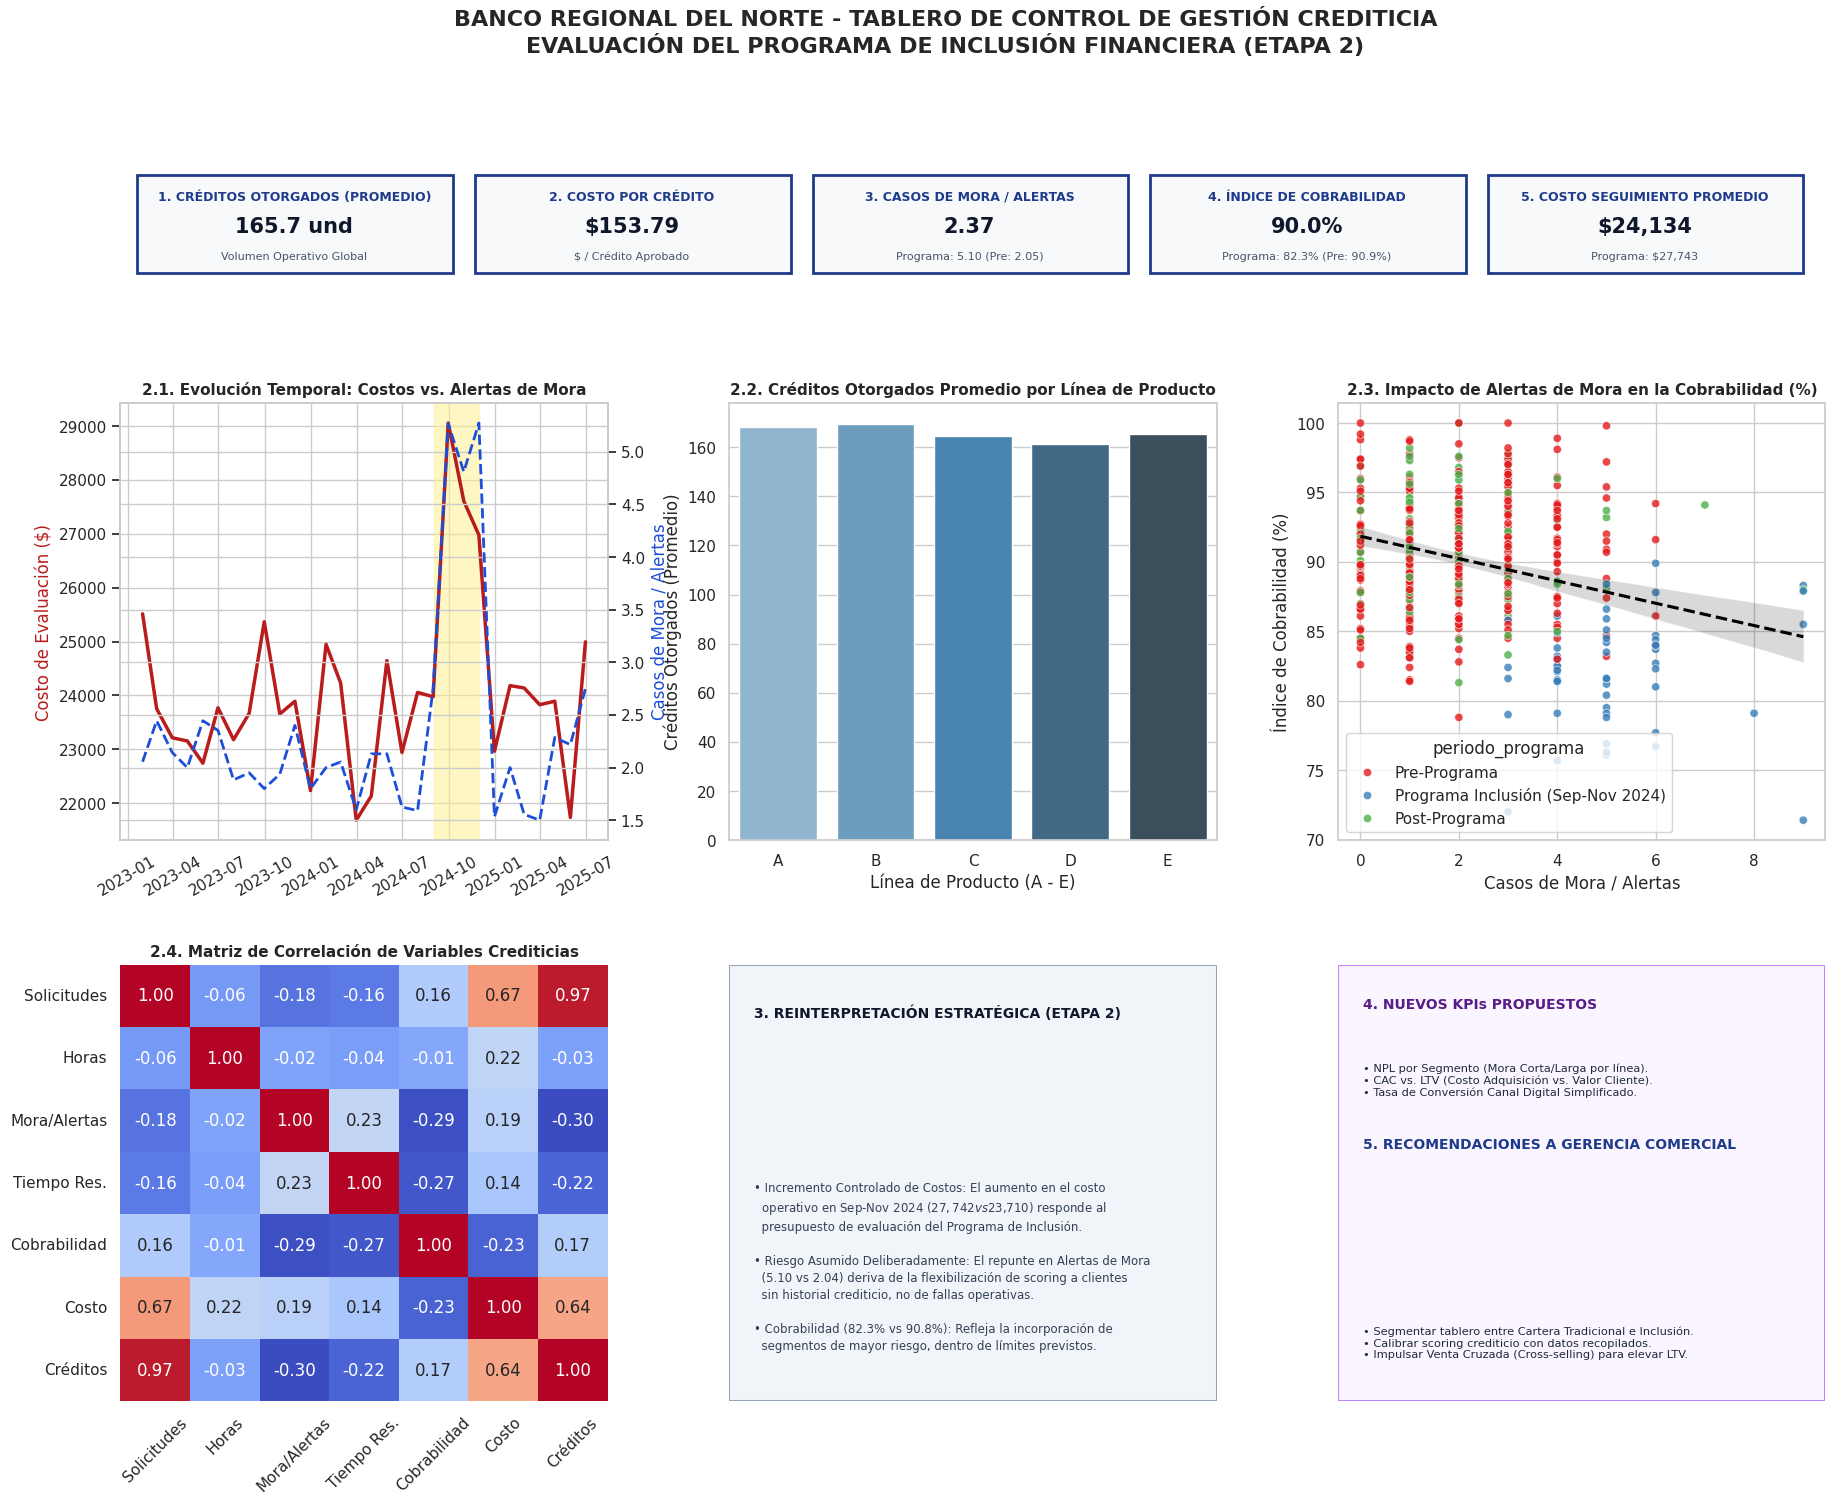

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo gráfico profesional
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'Segoe UI', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# 1. CARGA Y LIMPIEZA DE DATOS
# 1. Cargar y limpiar datos
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')

#url = 'https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/operacion_organizacion.csv'
#df = pd.read_csv(url)

# Eliminación de duplicados y conversión de fechas
df = df.drop_duplicates()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# 2. RENOMBRAMIENTO DE VARIABLES AL CONTEXTO BANCARIO (BANCO REGIONAL DEL NORTE)
rename_dict = {
    'ID': 'id_solicitud',
    'Fecha': 'fecha_operacion',
    'Unidad': 'linea_producto',
    'Region': 'region_sucursal',
    'Actividad': 'solicitudes_evaluadas',
    'Horas': 'horas_evaluacion',
    'Recursos': 'analistas_asignados',
    'Incidentes': 'casos_mora_alertas',
    'Tiempo': 'tiempo_resolucion_dias',
    'Calidad': 'indice_cobrabilidad',
    'Costo': 'costo_evaluacion_seguimiento',
    'Resultado': 'creditos_otorgados'
}

df_clean = df.rename(columns=rename_dict).copy()

# 3. CREACIÓN DE VARIABLES MÉTRICAS Y ETAPAS DEL PROGRAMA
df_clean['costo_por_credito'] = df_clean['costo_evaluacion_seguimiento'] / df_clean['creditos_otorgados']
df_clean['productividad_hora'] = df_clean['creditos_otorgados'] / df_clean['horas_evaluacion']

# Segmentar por período del Programa de Inclusión (Septiembre - Noviembre 2024)
df_clean['periodo_programa'] = df_clean['fecha_operacion'].apply(
    lambda x: 'Programa Inclusión (Sep-Nov 2024)' if pd.Timestamp('2024-09-01') <= x <= pd.Timestamp('2024-11-30')
    else ('Pre-Programa' if x < pd.Timestamp('2024-09-01') else 'Post-Programa')
)

# 4. CONFIGURACIÓN DEL DASHBOARD INTEGRADO DE ETAPA 2
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3, height_ratios=[0.25, 1, 1], hspace=0.38, wspace=0.25)

fig.suptitle('BANCO REGIONAL DEL NORTE - TABLERO DE CONTROL DE GESTIÓN CREDITICIA\n'
             'EVALUACIÓN DEL PROGRAMA DE INCLUSIÓN FINANCIERA (ETAPA 2)',
             fontsize=16, fontweight='bold', y=0.98)

# ----- PANEL 1: TARJETAS DE KPIs -----
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

inc_df = df_clean[df_clean['periodo_programa'] == 'Programa Inclusión (Sep-Nov 2024)']
pre_df = df_clean[df_clean['periodo_programa'] == 'Pre-Programa']

kpis = [
    ("1. CRÉDITOS OTORGADOS (PROMEDIO)", f"{df_clean['creditos_otorgados'].mean():.1f} und", "Volumen Operativo Global"),
    ("2. COSTO POR CRÉDITO", f"${df_clean['costo_por_credito'].mean():.2f}", "$ / Crédito Aprobado"),
    ("3. CASOS DE MORA / ALERTAS", f"{df_clean['casos_mora_alertas'].mean():.2f}", f"Programa: {inc_df['casos_mora_alertas'].mean():.2f} (Pre: {pre_df['casos_mora_alertas'].mean():.2f})"),
    ("4. ÍNDICE DE COBRABILIDAD", f"{df_clean['indice_cobrabilidad'].mean():.1f}%", f"Programa: {inc_df['indice_cobrabilidad'].mean():.1f}% (Pre: {pre_df['indice_cobrabilidad'].mean():.1f}%)"),
    ("5. COSTO SEGUIMIENTO PROMEDIO", f"${df_clean['costo_evaluacion_seguimiento'].mean():,.0f}", f"Programa: ${inc_df['costo_evaluacion_seguimiento'].mean():,.0f}")
]

for i, (title, val, sub) in enumerate(kpis):
    x = 0.01 + i * 0.198
    rect = plt.Rectangle((x, 0.05), 0.185, 0.9, transform=ax_kpi.transAxes,
                         facecolor='#f8f9fa', edgecolor='#1e3a8a', linewidth=2)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x + 0.092, 0.72, title, transform=ax_kpi.transAxes, ha='center', fontsize=9, fontweight='bold', color='#1e3a8a')
    ax_kpi.text(x + 0.092, 0.42, val, transform=ax_kpi.transAxes, ha='center', fontsize=15, fontweight='bold', color='#0f172a')
    ax_kpi.text(x + 0.092, 0.18, sub, transform=ax_kpi.transAxes, ha='center', fontsize=8, color='#475569')

# ----- PANEL 2.1: EVOLUCIÓN TEMPORAL (COSTOS VS ALERTAS) -----
ax1 = fig.add_subplot(gs[1, 0])
df_monthly = df_clean.resample('M', on='fecha_operacion')[['costo_evaluacion_seguimiento', 'casos_mora_alertas']].mean().reset_index()

ax1.plot(df_monthly['fecha_operacion'], df_monthly['costo_evaluacion_seguimiento'], color='#b91c1c', linewidth=2.5, label='Costo ($)')
ax1_twin = ax1.twinx()
ax1_twin.plot(df_monthly['fecha_operacion'], df_monthly['casos_mora_alertas'], color='#1d4ed8', linestyle='--', linewidth=2, label='Alertas Mora')
ax1.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), color='#fef08a', alpha=0.5, label='Programa Inclusión')
ax1.set_title('2.1. Evolución Temporal: Costos vs. Alertas de Mora', fontsize=11, fontweight='bold')
ax1.set_ylabel('Costo de Evaluación ($)', color='#b91c1c')
ax1_twin.set_ylabel('Casos de Mora / Alertas', color='#1d4ed8')
ax1.tick_params(axis='x', rotation=30)

# ----- PANEL 2.2: LÍNEA DE PRODUCTO -----
ax2 = fig.add_subplot(gs[1, 1])
linea_metrics = df_clean.groupby('linea_producto')['creditos_otorgados'].mean().reset_index()
sns.barplot(data=linea_metrics, x='linea_producto', y='creditos_otorgados', palette='Blues_d', ax=ax2)
ax2.set_title('2.2. Créditos Otorgados Promedio por Línea de Producto', fontsize=11, fontweight='bold')
ax2.set_xlabel('Línea de Producto (A - E)')
ax2.set_ylabel('Créditos Otorgados (Promedio)')

# ----- PANEL 2.3: IMPACTO DE MORA EN COBRABILIDAD -----
ax3 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df_clean, x='casos_mora_alertas', y='indice_cobrabilidad', hue='periodo_programa', palette='Set1', alpha=0.8, ax=ax3)
sns.regplot(data=df_clean, x='casos_mora_alertas', y='indice_cobrabilidad', scatter=False, ax=ax3, color='black', line_kws={'linestyle': '--'})
ax3.set_title('2.3. Impacto de Alertas de Mora en la Cobrabilidad (%)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Casos de Mora / Alertas')
ax3.set_ylabel('Índice de Cobrabilidad (%)')

# ----- PANEL 2.4: MATRIZ DE CORRELACIÓN -----
ax4 = fig.add_subplot(gs[2, 0])
corr_cols = ['solicitudes_evaluadas', 'horas_evaluacion', 'casos_mora_alertas', 'tiempo_resolucion_dias', 'indice_cobrabilidad', 'costo_evaluacion_seguimiento', 'creditos_otorgados']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=ax4, cbar=False,
            xticklabels=['Solicitudes', 'Horas', 'Mora/Alertas', 'Tiempo Res.', 'Cobrabilidad', 'Costo', 'Créditos'],
            yticklabels=['Solicitudes', 'Horas', 'Mora/Alertas', 'Tiempo Res.', 'Cobrabilidad', 'Costo', 'Créditos'])
ax4.set_title('2.4. Matriz de Correlación de Variables Crediticias', fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# ----- PANEL 2.5: TEXTO DE REINTERPRETACIÓN ESTRATÉGICA -----
ax_text1 = fig.add_subplot(gs[2, 1])
ax_text1.axis('off')
rect_c = plt.Rectangle((0, 0), 1, 1, transform=ax_text1.transAxes, facecolor='#f1f5f9', edgecolor='#94a3b8', linewidth=1.5)
ax_text1.add_patch(rect_c)
ax_text1.text(0.05, 0.88, '3. REINTERPRETACIÓN ESTRATÉGICA (ETAPA 2)', fontsize=10, fontweight='bold', color='#0f172a')
text_conclusiones = (
    "• Incremento Controlado de Costos: El aumento en el costo\n"
    "  operativo en Sep-Nov 2024 ($27,742 vs $23,710) responde al\n"
    "  presupuesto de evaluación del Programa de Inclusión.\n\n"
    "• Riesgo Asumido Deliberadamente: El repunte en Alertas de Mora\n"
    "  (5.10 vs 2.04) deriva de la flexibilización de scoring a clientes\n"
    "  sin historial crediticio, no de fallas operativas.\n\n"
    "• Cobrabilidad (82.3% vs 90.8%): Refleja la incorporación de\n"
    "  segmentos de mayor riesgo, dentro de límites previstos."
)
ax_text1.text(0.05, 0.12, text_conclusiones, fontsize=8.5, color='#334155', linespacing=1.4)

# ----- PANEL 2.6: DECISIONES Y NUEVOS KPIs -----
ax_text2 = fig.add_subplot(gs[2, 2])
ax_text2.axis('off')
rect_d = plt.Rectangle((0, 0), 1, 1, transform=ax_text2.transAxes, facecolor='#faf5ff', edgecolor='#c084fc', linewidth=1.5)
ax_text2.add_patch(rect_d)
ax_text2.text(0.05, 0.90, '4. NUEVOS KPIs PROPUESTOS', fontsize=10, fontweight='bold', color='#581c87')
text_decisiones = (
    "• NPL por Segmento (Mora Corta/Larga por línea).\n"
    "• CAC vs. LTV (Costo Adquisición vs. Valor Cliente).\n"
    "• Tasa de Conversión Canal Digital Simplificado."
)
ax_text2.text(0.05, 0.70, text_decisiones, fontsize=8.2, color='#1e293b')

ax_text2.text(0.05, 0.58, '5. RECOMENDACIONES A GERENCIA COMERCIAL', fontsize=10, fontweight='bold', color='#1e3a8a')
text_recom = (
    "• Segmentar tablero entre Cartera Tradicional e Inclusión.\n"
    "• Calibrar scoring crediticio con datos recopilados.\n"
    "• Impulsar Venta Cruzada (Cross-selling) para elevar LTV."
)
ax_text2.text(0.05, 0.10, text_recom, fontsize=8.2, color='#1e293b')

plt.savefig('tablero_banco_regional_norte_etapa2.png', bbox_inches='tight', dpi=300)
plt.show()